In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv(r'../010_missing_value_imputed_data/gurgaon_properties_missing_value_imputed.csv')

In [3]:
df.shape

(3554, 18)

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [5]:
latlong = pd.read_csv(r'./latlong.csv')

In [6]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [7]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [8]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [9]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [10]:
new_df = df.merge(latlong, on='sector')

In [11]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='object')

In [12]:
group_df = new_df.groupby('sector').mean(numeric_only=True)[['price','price_per_sqft','built_up_area','latitude','longitude']]

In [13]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 10,2.092857,11866.571429,1908.857143,28.4537,77.0009
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
...,...,...,...,...,...
sector 91,1.648235,7586.117647,2028.647059,28.4014,76.9225
sector 92,0.934000,5928.290000,1571.341800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326


In [14]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [15]:
new_df.to_csv(r'../016_real_estate_website/datasets/data_viz1.csv',index=False)

In [16]:
df1 = pd.read_csv(r'../003_cleaned_data/03_gurgaon_properties.csv')

In [17]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,2 BHK Flat in Sector 95A Gurgaon,flat,the roselia 2,0.45,6475.0,695.0,Built Up area: 695 (64.57 sq.m.)Carpet area: 5...,2.0,2.0,2.0,not available,"Sector 95a, Pataudi Road, Sector 95A Gurgaon, ...",19.0,North,undefined,NaN,Signature roselia 2 bhk. It is a good location...,NaN,NaN,"['Environment5 out of 5', 'Lifestyle4.5 out of..."
1,3 BHK Flat in Sector 92 Gurgaon,flat,bestech park view sanskruti,1.55,9687.0,1600.0,Super Built up area 1995(185.34 sq.m.)Carpet a...,3.0,3.0,3.0,servant room,"Sector 92, Sector 92 Gurgaon, Gurgaon, Haryana",17.0,NaN,1 to 5 Year Old,"['Sapphire 93 Mall', 'Dwarka Expressway', 'NH-...",Bestech sanskruti is well maintained society w...,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge...","['Intercom Facility', 'Lift(s)', 'Maintenance ...","['Green Area5 out of 5', 'Construction5 out of..."
2,2 BHK Flat in Sector 102 Gurgaon,flat,shapoorji pallonji joyville,1.10,12022.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 7...,2.0,2.0,1.0,not available,"Sector 102, Sector 102 Gurgaon, Gurgaon, Haryana",7.0,NaN,undefined,NaN,Best in class property available at sector 102...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,"['Environment4 out of 5', 'Lifestyle4.5 out of..."
3,2 BHK Flat in Sohna,flat,signature global park,0.67,5537.0,1210.0,Super Built up area 1210(112.41 sq.m.),2.0,2.0,3.0,pooja room,"001, Sohna, Gurgaon, Haryana",4.0,North-East,1 to 5 Year Old,"['Sector 55-56 metro', 'Global city centre', '...","Signature global park in sohna, gurgaon is a r...",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Green Area5 out of 5', 'Construction5 out of..."
4,2 BHK Flat in Sector 85 Gurgaon,flat,godrej air,1.40,10000.0,1400.0,Built Up area: 1400 (130.06 sq.m.)Carpet area:...,2.0,2.0,3.0,not available,"Sector 85, Sector 85 Gurgaon, Gurgaon, Haryana",23.0,NaN,undefined,"['Sapphire 83 Mall', 'Sector 86 Road', 'Dwarka...",Multistorey apartment is available for sale. I...,NaN,NaN,"['Environment5 out of 5', 'Lifestyle5 out of 5..."


In [18]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [19]:
wordcloud_df.head()

,features,sector
0,NaN,sector 36
1,"['Intercom Facility', 'Lift(s)', 'Maintenance ...",sector 89
2,NaN,sohna road
3,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 92
4,NaN,sector 102


In [20]:
import ast
main = []

for row in wordcloud_df['features'].dropna():
    try:
        # Try to convert the string to a list
        item = ast.literal_eval(row)
        main.extend(item)
    except (ValueError, SyntaxError):
        # This catches strings that aren't properly formatted
        print(f"Skipping malformed row: {row}")
        continue


Skipping malformed row: features


In [21]:
main

['Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Internet/wi-fi connectivity',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Rain Water Harvesting',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Lift(s)',
 'Water purifier',
 'Centrally Air Conditioned',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Recently Renovated',
 'Piped-gas',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Natural Light',
 'Internet/wi-fi connectivity',
 'Airy Rooms',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Water softening plant',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Maintenance Staff',
 'Water Storage',
 'Visitor Parking',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Water Storage',
 'Park',
 'Fitness Centre / GYM',
 'Feng Shui

In [22]:
from wordcloud import WordCloud

In [23]:
feature_text = ' '.join(main)

In [24]:
import pickle
pickle.dump(feature_text, open(r'../016_real_estate_website/datasets/feature_text.pkl','wb'))

In [25]:
feature_text

'Intercom Facility Lift(s) Maintenance Staff Swimming Pool Park Security Personnel Internet/wi-fi connectivity Fitness Centre / GYM Club house / Community Center Rain Water Harvesting Security / Fire Alarm Feng Shui / Vaastu Compliant Lift(s) Water purifier Centrally Air Conditioned High Ceiling Height Maintenance Staff Water Storage Separate entry for servant room No open drainage around Recently Renovated Piped-gas Visitor Parking Swimming Pool Park Natural Light Internet/wi-fi connectivity Airy Rooms Shopping Centre Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Water softening plant Feng Shui / Vaastu Compliant Private Garden / Terrace Maintenance Staff Water Storage Visitor Parking Waste Disposal Rain Water Harvesting Water Storage Park Fitness Centre / GYM Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Park Visitor Parking Private Garden / Terrace Maintenance Staff Water Storage

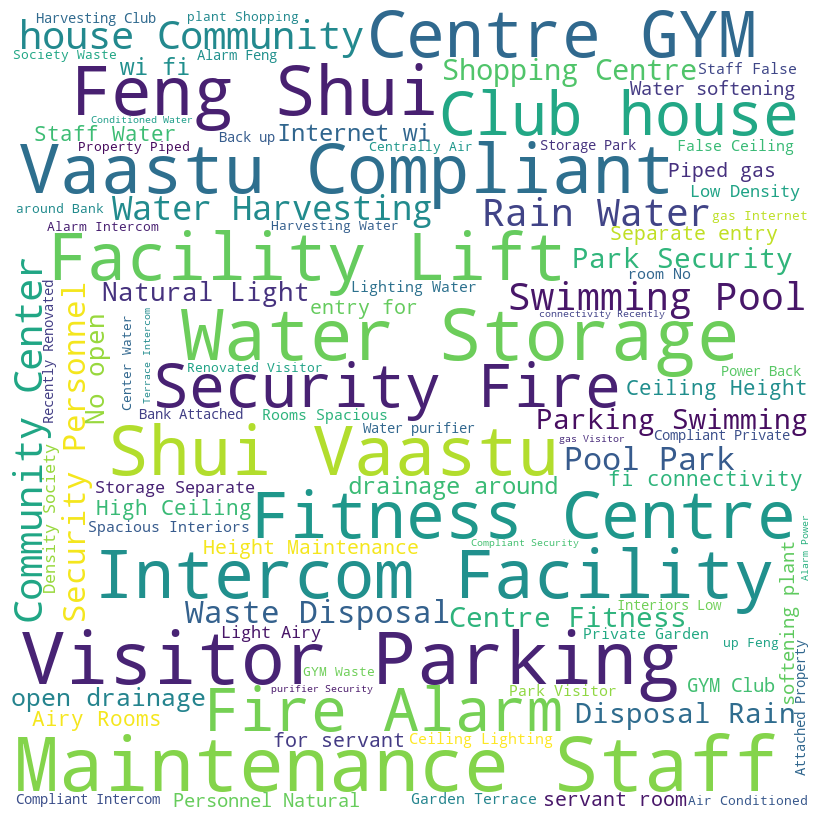

In [26]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [27]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [28]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [29]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [30]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()


C:\Users\rudra\AppData\Local\Temp\ipykernel_11100\3761596323.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


d:\DSMP_CAPSTONE\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\rudra\AppData\Local\Temp\ipykernel_11100\3761596323.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updatin

<Axes: xlabel='price', ylabel='Density'>

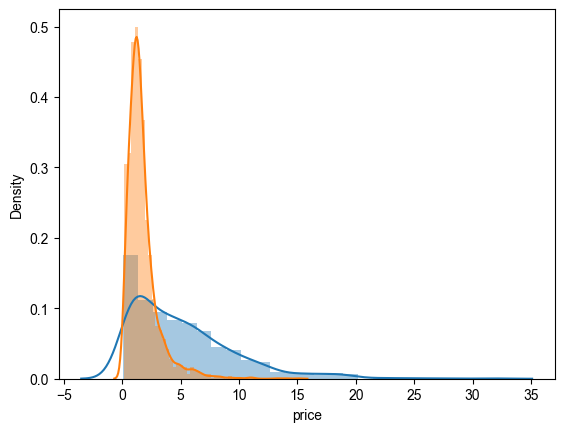

In [31]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])

In [32]:
new_df['sector'].unique().tolist().insert(0,'overall')